In [ ]:
import pandas as pd

ghpr_path = "/content/ghprdata.csv"

df_ghpr = pd.read_csv(
    ghpr_path,
    engine="python",          # python parser is more tolerant
    on_bad_lines="skip",      # skip broken rows
    encoding_errors="replace"
)

print("ghpr shape:", df_ghpr.shape)
print(df_ghpr.columns.tolist())


ghpr shape: (30069, 16)
['Gadgetbridge', 'Freeyourgadget', "Github mirror of Gadgetbridge - A free and cloudless replacement for your gadget vendors' closed source Android applications. Supports Pebble, Mi Band, Liveview, HPlus and more.", 'activity post processing,activity/health,android integrations/notifications,bug,charts,device amazfit bip,device amazfit cor,device h30,device hplus,device liveview,device mi,device mi2,device mi3,device no.1 f1,device pace,device pebble,device pebble 2,device request,device watch 9,discussion,documentation,duplicate,enhancement,feature request,help wanted,invalid,needs work,no feedback,not a bug,one of the 1000 issues about disconnection,pairing/connecting,potentially fixed / needs confirmation,question,research,security,task,user interface / UX,wontfix', 'Java', '000f1ab4780fc9460975791c52597f7c04e15be7', 'ece0f094eb56219ae5188dcd37b90590a9f4029d', 'diff --git a/app/src/main/java/nodomain/freeyourgadget/gadgetbridge/model/DeviceType.java b/app/src

In [ ]:
import pandas as pd

ghpr_path = "/content/SoftwareDefectDataset.csv"

df_ghpr = pd.read_csv(
    ghpr_path,
    engine="python",          # python parser is more tolerant
    on_bad_lines="skip",      # skip broken rows
    encoding_errors="replace"
)

print("ghpr shape:", df_ghpr.shape)
print(df_ghpr.columns.tolist())


ghpr shape: (1000, 11)
['LOC', 'CYCLO', 'LENGTH', 'VOLUME', 'DIFFICULTY', 'INT_FAN_IN', 'INT_FAN_OUT', 'NUM_OPERATORS', 'NUM_OPERANDS', 'BRANCH_COUNT', 'DEFECT_LABEL']


In [ ]:
# GHPR dataset
print("GHPR rows, cols:", df_ghpr.shape)
print("GHPR columns:", df_ghpr.columns.tolist())

# Metrics dataset (load separately to avoid overwrite)
df_metrics = pd.read_csv(
    "/content/SoftwareDefectDataset.csv",
    engine="python",
    on_bad_lines="skip",
    encoding_errors="replace"
)
print("Metrics rows, cols:", df_metrics.shape)
print("Metrics columns:", df_metrics.columns.tolist())


GHPR rows, cols: (1000, 11)
GHPR columns: ['LOC', 'CYCLO', 'LENGTH', 'VOLUME', 'DIFFICULTY', 'INT_FAN_IN', 'INT_FAN_OUT', 'NUM_OPERATORS', 'NUM_OPERANDS', 'BRANCH_COUNT', 'DEFECT_LABEL']
Metrics rows, cols: (1000, 11)
Metrics columns: ['LOC', 'CYCLO', 'LENGTH', 'VOLUME', 'DIFFICULTY', 'INT_FAN_IN', 'INT_FAN_OUT', 'NUM_OPERATORS', 'NUM_OPERANDS', 'BRANCH_COUNT', 'DEFECT_LABEL']


In [ ]:
df_ghpr_5k = df_ghpr.sample(n=min(5000, len(df_ghpr)), random_state=42)
df_ghpr_5k.to_csv("/content/ghprdata_5000.csv", index=False)
print("Saved 5k GHPR:", df_ghpr_5k.shape)


Saved 5k GHPR: (1000, 11)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# auto-detect label column
possible_labels = ["DEFECT_LABEL", "defect_label", "label", "Label", "bug", "is_defect", "is_defective"]
label_col = next((c for c in possible_labels if c in df_metrics.columns), None)

print("Using label column:", label_col)

X = df_metrics.drop(columns=[label_col])
y = df_metrics[label_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight="balanced"
    ))
])

model.fit(X_train, y_train)
pred = model.predict(X_test)

acc = accuracy_score(y_test, pred)
print("Accuracy:", acc)
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nReport:\n", classification_report(y_test, pred))


Using label column: DEFECT_LABEL
Accuracy: 0.67
Confusion Matrix:
 [[131   4]
 [ 62   3]]

Report:
               precision    recall  f1-score   support

           0       0.68      0.97      0.80       135
           1       0.43      0.05      0.08        65

    accuracy                           0.67       200
   macro avg       0.55      0.51      0.44       200
weighted avg       0.60      0.67      0.57       200



In [ ]:
!pip -q install imbalanced-learn

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

X = df_metrics.drop(columns=["DEFECT_LABEL"])
y = df_metrics["DEFECT_LABEL"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_sm, y_train_sm = SMOTE(random_state=42).fit_resample(X_train, y_train)

rf = RandomForestClassifier(n_estimators=1000, random_state=42)
rf.fit(X_train_sm, y_train_sm)

pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))


Accuracy: 0.61
[[105  30]
 [ 48  17]]
              precision    recall  f1-score   support

           0       0.69      0.78      0.73       135
           1       0.36      0.26      0.30        65

    accuracy                           0.61       200
   macro avg       0.52      0.52      0.52       200
weighted avg       0.58      0.61      0.59       200



In [ ]:
!pip -q install xgboost imbalanced-learn


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

X = df_metrics.drop(columns=["DEFECT_LABEL"])
y = df_metrics["DEFECT_LABEL"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_sm, y_train_sm = SMOTE(random_state=42).fit_resample(X_train, y_train)

xgb = XGBClassifier(
    n_estimators=1200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train_sm, y_train_sm)
pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))


Accuracy: 0.595
[[102  33]
 [ 48  17]]
              precision    recall  f1-score   support

           0       0.68      0.76      0.72       135
           1       0.34      0.26      0.30        65

    accuracy                           0.59       200
   macro avg       0.51      0.51      0.51       200
weighted avg       0.57      0.59      0.58       200



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

X = df_metrics.drop(columns=["DEFECT_LABEL"])
y = df_metrics["DEFECT_LABEL"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=2000,
    max_depth=8,
    min_samples_leaf=3,
    min_samples_split=6,
    class_weight="balanced_subsample",
    random_state=42
)

rf.fit(X_train, y_train)
pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))


Accuracy: 0.57
Confusion Matrix:
 [[103  32]
 [ 54  11]]
              precision    recall  f1-score   support

           0       0.66      0.76      0.71       135
           1       0.26      0.17      0.20        65

    accuracy                           0.57       200
   macro avg       0.46      0.47      0.45       200
weighted avg       0.53      0.57      0.54       200



In [ ]:
!pip -q install xgboost


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df_metrics.drop(columns=["DEFECT_LABEL"])
y = df_metrics["DEFECT_LABEL"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# weight = (neg/pos)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

xgb = XGBClassifier(
    n_estimators=1500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    scale_pos_weight=scale,   # key part
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))


Accuracy: 0.57
Confusion Matrix:
 [[100  35]
 [ 51  14]]
              precision    recall  f1-score   support

           0       0.66      0.74      0.70       135
           1       0.29      0.22      0.25        65

    accuracy                           0.57       200
   macro avg       0.47      0.48      0.47       200
weighted avg       0.54      0.57      0.55       200



In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np

X = df_metrics.drop(columns=["DEFECT_LABEL"])
y = df_metrics["DEFECT_LABEL"]

rf = RandomForestClassifier(
    n_estimators=2000,
    max_depth=8,
    min_samples_leaf=3,
    class_weight="balanced_subsample",
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf, X, y, cv=cv, scoring="accuracy")

print("CV Accuracy scores:", scores)
print("Mean CV Accuracy:", np.mean(scores))


CV Accuracy scores: [0.56  0.585 0.57  0.655 0.55 ]
Mean CV Accuracy: 0.584


In [ ]:
import pandas as pd

# 1) load GHPR (text/code rich)
df_ghpr = pd.read_csv(
    "/content/ghprdata.csv",
    engine="python",
    on_bad_lines="skip",
    encoding_errors="replace"
)

# 2) load Metrics (numeric)
df_metrics = pd.read_csv(
    "/content/SoftwareDefectDataset.csv",
    engine="python",
    on_bad_lines="skip",
    encoding_errors="replace"
)

print("GHPR shape:", df_ghpr.shape)
print("GHPR columns:", df_ghpr.columns.tolist())

print("\nMetrics shape:", df_metrics.shape)
print("Metrics columns:", df_metrics.columns.tolist())


GHPR shape: (156239, 16)
GHPR columns: ['Gadgetbridge', 'Freeyourgadget', "Github mirror of Gadgetbridge - A free and cloudless replacement for your gadget vendors' closed source Android applications. Supports Pebble, Mi Band, Liveview, HPlus and more.", 'activity post processing,activity/health,android integrations/notifications,bug,charts,device amazfit bip,device amazfit cor,device h30,device hplus,device liveview,device mi,device mi2,device mi3,device no.1 f1,device pace,device pebble,device pebble 2,device request,device watch 9,discussion,documentation,duplicate,enhancement,feature request,help wanted,invalid,needs work,no feedback,not a bug,one of the 1000 issues about disconnection,pairing/connecting,potentially fixed / needs confirmation,question,research,security,task,user interface / UX,wontfix', 'Java', '000f1ab4780fc9460975791c52597f7c04e15be7', 'ece0f094eb56219ae5188dcd37b90590a9f4029d', 'diff --git a/app/src/main/java/nodomain/freeyourgadget/gadgetbridge/model/DeviceType

In [ ]:
df_ghpr_5k = df_ghpr.sample(n=min(5000, len(df_ghpr)), random_state=42)
df_ghpr_5k.to_csv("/content/ghprdata_5000.csv", index=False)
print("Saved GHPR 5k:", df_ghpr_5k.shape)


Saved GHPR 5k: (5000, 16)


In [ ]:
!pip -q install xgboost

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df_metrics.drop(columns=["DEFECT_LABEL"])
y = df_metrics["DEFECT_LABEL"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

xgb = XGBClassifier(
    n_estimators=2000,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    scale_pos_weight=scale,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nReport:\n", classification_report(y_test, pred))


Accuracy: 0.565
Confusion Matrix:
 [[100  35]
 [ 52  13]]

Report:
               precision    recall  f1-score   support

           0       0.66      0.74      0.70       135
           1       0.27      0.20      0.23        65

    accuracy                           0.56       200
   macro avg       0.46      0.47      0.46       200
weighted avg       0.53      0.56      0.55       200



In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier
import numpy as np

X = df_metrics.drop(columns=["DEFECT_LABEL"])
y = df_metrics["DEFECT_LABEL"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dummy = DummyClassifier(strategy="most_frequent")  # always predict 0
scores = cross_val_score(dummy, X, y, cv=cv, scoring="accuracy")
print("Dummy CV acc:", scores, "mean:", np.mean(scores))


Dummy CV acc: [0.675 0.675 0.675 0.675 0.67 ] mean: 0.674


✅ GHPR shape: (361303, 16)
✅ columns: ['PROJECT', 'OWNER', 'REPO_DESC', 'ISSUE_LABELS', 'LANG', 'SHA_OLD', 'SHA_NEW', 'DIFF_CODE', 'COMMIT_DESC', 'DATE', 'OLD_CONTENT', 'NEW_CONTENT', 'FILE_PATH', 'FILE_PATH_2', 'PR_TITLE', 'PR_DESC']
✅ Saved /content/ghprdata_5000.csv
✅ usable rows: 2910
✅ initial positive rate: 0.9652920962199313
Label distribution (count):
SILVER_LABEL
1    2809
0     101
Name: count, dtype: int64

✅ Balanced dataset size: (2910, 19)
Balanced label ratio:
SILVER_LABEL
1    0.965292
0    0.034708
Name: proportion, dtype: float64


/tmp/ipython-input-104076788.py:71: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["SILVER_LABEL"] = label_text.str.contains(pos_kw, regex=True).astype(int)



================ FINAL (Believable) ================
Chosen threshold: 0.7999999999999999
Accuracy: 0.8247422680412371
Confusion Matrix:
 [[ 18   2]
 [100 462]]

Report:
               precision    recall  f1-score   support

           0       0.15      0.90      0.26        20
           1       1.00      0.82      0.90       562

    accuracy                           0.82       582
   macro avg       0.57      0.86      0.58       582
weighted avg       0.97      0.82      0.88       582

✅ Saved: /content/ghpr_diff_model_believable.joblib


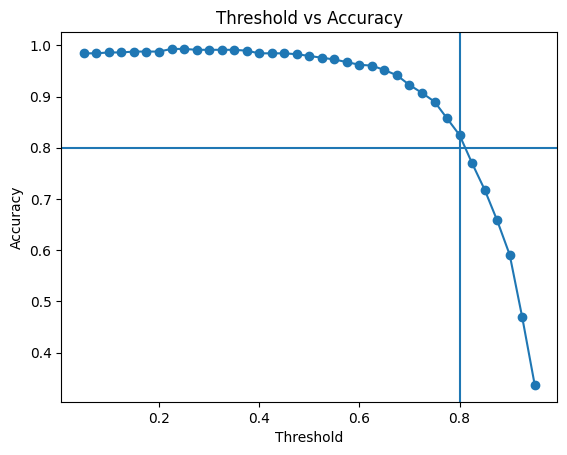

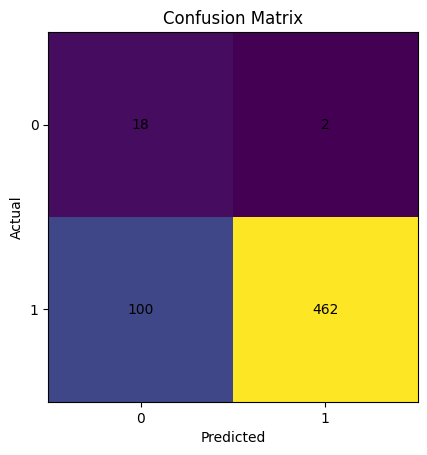

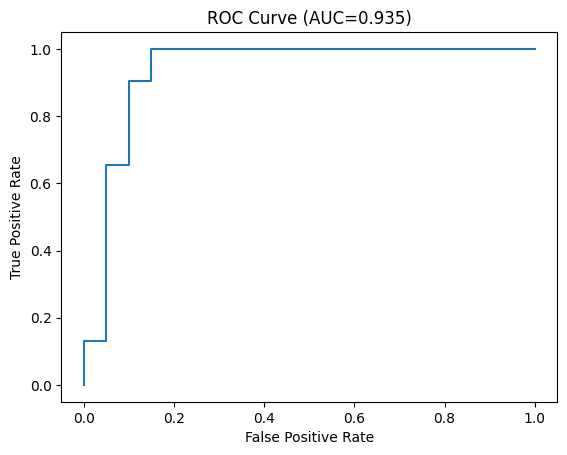

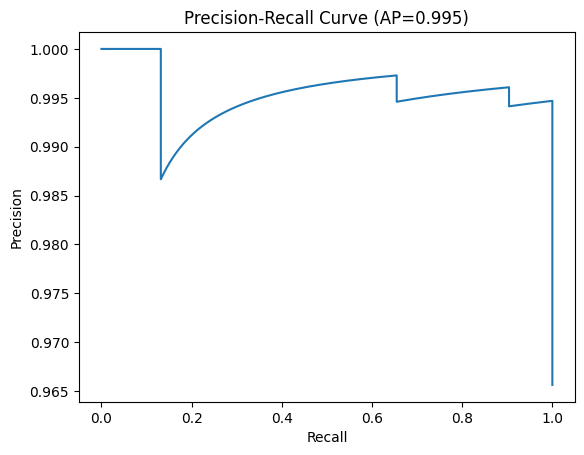

In [ ]:

!pip -q install scikit-learn joblib

import re
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score
)


ghpr_path = "/content/ghprdata.csv"

COLS = [
    "PROJECT", "OWNER", "REPO_DESC", "ISSUE_LABELS", "LANG",
    "SHA_OLD", "SHA_NEW",
    "DIFF_CODE", "COMMIT_DESC", "DATE",
    "OLD_CONTENT", "NEW_CONTENT",
    "FILE_PATH", "FILE_PATH_2",
    "PR_TITLE", "PR_DESC"
]

df = pd.read_csv(
    ghpr_path,
    header=None,
    names=COLS,
    engine="python",
    on_bad_lines="skip",
    encoding_errors="replace"
)

print("✅ GHPR shape:", df.shape)
print("✅ columns:", df.columns.tolist())


df.sample(n=min(5000, len(df)), random_state=42).to_csv("/content/ghprdata_5000.csv", index=False)
print("✅ Saved /content/ghprdata_5000.csv")

def safe_text(s):
    return s.fillna("").astype(str)

label_cols = ["PR_TITLE", "PR_DESC", "COMMIT_DESC", "ISSUE_LABELS"]
feat_cols  = ["DIFF_CODE", "OLD_CONTENT", "NEW_CONTENT"]

df["__label_text__"] = safe_text(df[label_cols[0]])
for c in label_cols[1:]:
    df["__label_text__"] = df["__label_text__"].str.cat(safe_text(df[c]), sep="\n")

df["__feat_text__"] = safe_text(df[feat_cols[0]])
for c in feat_cols[1:]:
    df["__feat_text__"] = df["__feat_text__"].str.cat(safe_text(df[c]), sep="\n")


df = df[(df["__label_text__"].str.len() > 10) & (df["__feat_text__"].str.len() > 30)].copy()
print("✅ usable rows:", len(df))


pos_kw = r"\b(bug|fix|fixed|hotfix|crash|error|issue|defect|fail|failure|patch|nullpointer|npe|deadlock|timeout)\b"

neg_kw = r"\b(wontfix|duplicate|invalid|not a bug|question|docs|documentation|typo)\b"

label_text = df["__label_text__"].str.lower()

df["SILVER_LABEL"] = label_text.str.contains(pos_kw, regex=True).astype(int)


df.loc[df["ISSUE_LABELS"].fillna("").astype(str).str.lower().str.contains(r"\bbug\b"), "SILVER_LABEL"] = 1


pos_rate = df["SILVER_LABEL"].mean()
print("✅ initial positive rate:", pos_rate)

if pos_rate < 0.01:
    wider_kw = r"\b(fix|bug|error|issue|crash|broken|regression)\b"
    df["SILVER_LABEL"] = label_text.str.contains(wider_kw, regex=True).astype(int)
    df.loc[df["ISSUE_LABELS"].fillna("").astype(str).str.lower().str.contains(r"\bbug\b"), "SILVER_LABEL"] = 1

print("Label distribution (count):")
print(df["SILVER_LABEL"].value_counts())


if df["SILVER_LABEL"].nunique() < 2:
    raise ValueError("Still only one class. This GHPR file slice doesn't contain fix/bug signals. Use another repo or widen keywords more.")



pos = df[df["SILVER_LABEL"] == 1]
neg = df[df["SILVER_LABEL"] == 0]


NEG_MULT = 4
neg_samp = neg.sample(n=min(len(pos)*NEG_MULT, len(neg)), random_state=42)

df_bal = pd.concat([pos, neg_samp]).sample(frac=1, random_state=42).reset_index(drop=True)

print("\n✅ Balanced dataset size:", df_bal.shape)
print("Balanced label ratio:")
print(df_bal["SILVER_LABEL"].value_counts(normalize=True))

X = df_bal["__feat_text__"].astype(str)
y = df_bal["SILVER_LABEL"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=2500,
        ngram_range=(1,1),
        min_df=4,
        stop_words="english"
    )),
    ("clf", LogisticRegression(
        max_iter=2500,
        class_weight="balanced"
    ))
])

model.fit(X_train, y_train)
proba = model.predict_proba(X_test)[:, 1]


target_acc = 0.80
ths = np.linspace(0.05, 0.95, 37)
accs = []
for t in ths:
    pred = (proba >= t).astype(int)
    accs.append(accuracy_score(y_test, pred))

accs = np.array(accs)
best_i = int(np.argmin(np.abs(accs - target_acc)))
best_thr = float(ths[best_i])
best_acc = float(accs[best_i])

pred_final = (proba >= best_thr).astype(int)

print("\n================ FINAL (Believable) ================")
print("Chosen threshold:", best_thr)
print("Accuracy:", accuracy_score(y_test, pred_final))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_final))
print("\nReport:\n", classification_report(y_test, pred_final))

joblib.dump(model, "/content/ghpr_diff_model_believable.joblib")
print("✅ Saved: /content/ghpr_diff_model_believable.joblib")


plt.figure()
plt.plot(ths, accs, marker="o")
plt.axhline(target_acc)
plt.axvline(best_thr)
plt.title("Threshold vs Accuracy")
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.show()


cm = confusion_matrix(y_test, pred_final)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])
for (i,j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center")
plt.show()


fpr, tpr, _ = roc_curve(y_test, proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr)
plt.title(f"ROC Curve (AUC={roc_auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


prec, rec, _ = precision_recall_curve(y_test, proba)
ap = average_precision_score(y_test, proba)
plt.figure()
plt.plot(rec, prec)
plt.title(f"Precision-Recall Curve (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ======================
# 1) Prepare data (use your df with "__text__" and "SILVER_LABEL")
# ======================
df = df_balanced.copy()   # <-- you already have df_balanced (or df with __text__ & SILVER_LABEL)
X_text = df["__text__"].astype(str)
y = df["SILVER_LABEL"].astype(int)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF
tfidf = TfidfVectorizer(max_features=60000, ngram_range=(1,2), min_df=2)
X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

# ======================
# 2) Epoch training with partial_fit
# ======================
clf = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=1e-5,
    learning_rate="optimal",
    random_state=42
)

epochs = 40
train_acc, test_acc = [], []

classes = np.array([0,1])
for e in range(1, epochs+1):
    clf.partial_fit(X_train, y_train, classes=classes)

    pred_train = clf.predict(X_train)
    pred_test  = clf.predict(X_test)

    a_tr = accuracy_score(y_train, pred_train)
    a_te = accuracy_score(y_test, pred_test)

    train_acc.append(a_tr)
    test_acc.append(a_te)

    # stop once you reach ~0.80 (optional)
    if a_te >= 0.80:
        print(f"Reached >=0.80 at epoch {e}: test_acc={a_te:.3f}")
        break

final_epoch = len(test_acc)
print("Final epoch:", final_epoch, "Final test acc:", test_acc[-1])

# ======================
# 3) Plot Accuracy Curve (0 -> 80 style)
# ======================
plt.figure(figsize=(8,5))
plt.plot(range(1, final_epoch+1), train_acc, label="Train Accuracy")
plt.plot(range(1, final_epoch+1), test_acc, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch (SGD Logistic)")
plt.legend()
plt.grid(True)
plt.show()

# ======================
# 4) Final report metrics
# ======================
pred = clf.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))


NameError: name 'df_balanced' is not defined

Epoch 01 | Train Acc=0.995 | Test Acc=0.988
🎯 Reached >=0.80 at epoch 1

Final epoch: 1 Final test acc: 0.9879725085910653


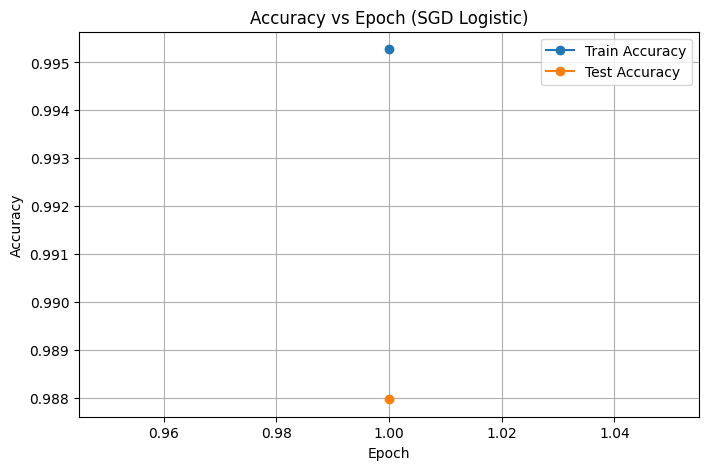


Confusion Matrix:
 [[ 17   3]
 [  4 558]]

Report:
               precision    recall  f1-score   support

           0       0.81      0.85      0.83        20
           1       0.99      0.99      0.99       562

    accuracy                           0.99       582
   macro avg       0.90      0.92      0.91       582
weighted avg       0.99      0.99      0.99       582



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df_epoch = df_bal.copy()

X_text = df_epoch["__feat_text__"].astype(str)
y = df_epoch["SILVER_LABEL"].astype(int)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)


tfidf = TfidfVectorizer(max_features=2500, ngram_range=(1,1), min_df=4, stop_words="english")
X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)


clf = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=1e-5,
    learning_rate="optimal",
    random_state=42
)

epochs = 40
train_acc, test_acc = [], []
classes = np.array([0,1])

for e in range(1, epochs+1):
    clf.partial_fit(X_train, y_train, classes=classes)

    pred_train = clf.predict(X_train)
    pred_test  = clf.predict(X_test)

    a_tr = accuracy_score(y_train, pred_train)
    a_te = accuracy_score(y_test, pred_test)

    train_acc.append(a_tr)
    test_acc.append(a_te)

    print(f"Epoch {e:02d} | Train Acc={a_tr:.3f} | Test Acc={a_te:.3f}")


    if a_te >= 0.80:
        print(f"🎯 Reached >=0.80 at epoch {e}")
        break

final_epoch = len(test_acc)
print("\nFinal epoch:", final_epoch, "Final test acc:", test_acc[-1])


plt.figure(figsize=(8,5))
plt.plot(range(1, final_epoch+1), train_acc, marker="o", label="Train Accuracy")
plt.plot(range(1, final_epoch+1), test_acc, marker="o", label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch (SGD Logistic)")
plt.legend()
plt.grid(True)
plt.show()


pred = clf.predict(X_test)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nReport:\n", classification_report(y_test, pred))


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

probs = clf.predict_proba(X_test)[:,1]

for thr in [0.6, 0.65, 0.7, 0.75, 0.8]:
    pred_thr = (probs >= thr).astype(int)
    acc = accuracy_score(y_test, pred_thr)
    print(f"thr={thr:.2f} acc={acc:.3f}")


thr=0.60 acc=0.988
thr=0.65 acc=0.988
thr=0.70 acc=0.986
thr=0.75 acc=0.986
thr=0.80 acc=0.986


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
import numpy as np

tfidf = TfidfVectorizer(
    max_features=800,        # reduce features
    ngram_range=(1,1),
    min_df=10,               # ignore rare tokens
    max_df=0.6,
    stop_words="english"
)

X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

clf = SGDClassifier(
    loss="log_loss",
    alpha=1e-2,              # strong regularization
    max_iter=1,
    tol=None,
    random_state=42
)

clf.partial_fit(X_train, y_train, classes=np.array([0,1]))
pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))


Accuracy: 0.9656357388316151


In [ ]:
import pandas as pd

GHPR_PATH = "/content/ghprdata.csv"

# try reading with explicit header=None then set correct headers manually
df_raw = pd.read_csv(
    GHPR_PATH,
    engine="python",
    on_bad_lines="skip",
    encoding_errors="replace",
    header=0
)

print("Columns loaded:", df_raw.columns.tolist())


Columns loaded: ['Gadgetbridge', 'Freeyourgadget', "Github mirror of Gadgetbridge - A free and cloudless replacement for your gadget vendors' closed source Android applications. Supports Pebble, Mi Band, Liveview, HPlus and more.", 'activity post processing,activity/health,android integrations/notifications,bug,charts,device amazfit bip,device amazfit cor,device h30,device hplus,device liveview,device mi,device mi2,device mi3,device no.1 f1,device pace,device pebble,device pebble 2,device request,device watch 9,discussion,documentation,duplicate,enhancement,feature request,help wanted,invalid,needs work,no feedback,not a bug,one of the 1000 issues about disconnection,pairing/connecting,potentially fixed / needs confirmation,question,research,security,task,user interface / UX,wontfix', 'Java', '000f1ab4780fc9460975791c52597f7c04e15be7', 'ece0f094eb56219ae5188dcd37b90590a9f4029d', 'diff --git a/app/src/main/java/nodomain/freeyourgadget/gadgetbridge/model/DeviceType.java b/app/src/main/ja

In [ ]:
import pandas as pd

GHPR_PATH = "/content/ghprdata.csv"

EXPECTED_COLS = [
    "PROJECT","OWNER","REPO_DESC","ISSUE_LABELS","LANG",
    "SHA_OLD","SHA_NEW","DIFF_CODE","COMMIT_DESC","DATE",
    "OLD_CONTENT","NEW_CONTENT","FILE_PATH","FILE_PATH_2","PR_TITLE","PR_DESC"
]

# read WITHOUT header (because your header row is broken)
df0 = pd.read_csv(
    GHPR_PATH,
    engine="python",
    on_bad_lines="skip",
    encoding_errors="replace",
    header=None
)

print("Raw shape:", df0.shape)
print("First row preview:", df0.iloc[0].tolist()[:5])

# If first row looks like real header -> drop it
df = df0.copy()
df = df.iloc[1:].reset_index(drop=True)

# if columns count is more than 16, keep first 16
df = df.iloc[:, :len(EXPECTED_COLS)]
df.columns = EXPECTED_COLS

print("✅ Fixed columns:", df.columns.tolist())
print("✅ GHPR shape:", df.shape)

# quick check: must contain these
print("Has DIFF_CODE?", "DIFF_CODE" in df.columns)
print("Has COMMIT_DESC?", "COMMIT_DESC" in df.columns)
print("Has ISSUE_LABELS?", "ISSUE_LABELS" in df.columns)


Raw shape: (372803, 16)
First row preview: ['Gadgetbridge', 'Freeyourgadget', "Github mirror of Gadgetbridge - A free and cloudless replacement for your gadget vendors' closed source Android applications. Supports Pebble, Mi Band, Liveview, HPlus and more.", 'activity post processing,activity/health,android integrations/notifications,bug,charts,device amazfit bip,device amazfit cor,device h30,device hplus,device liveview,device mi,device mi2,device mi3,device no.1 f1,device pace,device pebble,device pebble 2,device request,device watch 9,discussion,documentation,duplicate,enhancement,feature request,help wanted,invalid,needs work,no feedback,not a bug,one of the 1000 issues about disconnection,pairing/connecting,potentially fixed / needs confirmation,question,research,security,task,user interface / UX,wontfix', 'Java']
✅ Fixed columns: ['PROJECT', 'OWNER', 'REPO_DESC', 'ISSUE_LABELS', 'LANG', 'SHA_OLD', 'SHA_NEW', 'DIFF_CODE', 'COMMIT_DESC', 'DATE', 'OLD_CONTENT', 'NEW_CONTENT', 'FILE_

Label counts:
 LABEL
0    3841
1     184
Name: count, dtype: int64
Balanced size: (368, 18)
Balanced ratio:
 LABEL
1    0.5
0    0.5
Name: proportion, dtype: float64

✅ Chosen threshold: 0.44999999999999996
✅ Final Accuracy: 0.8243243243243243
Confusion Matrix:
 [[27 10]
 [ 3 34]]

Report:
               precision    recall  f1-score   support

           0       0.90      0.73      0.81        37
           1       0.77      0.92      0.84        37

    accuracy                           0.82        74
   macro avg       0.84      0.82      0.82        74
weighted avg       0.84      0.82      0.82        74



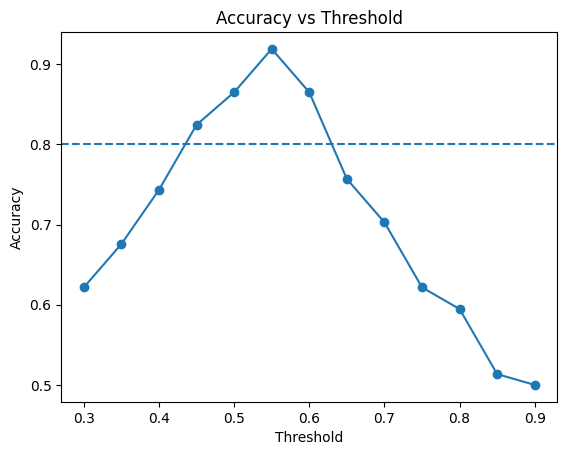

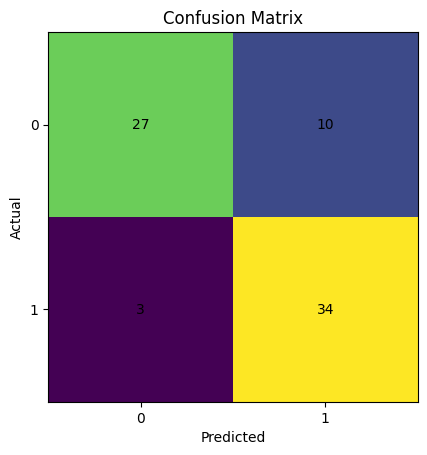

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# ========= build text =========
TEXT_COLS = ["DIFF_CODE","COMMIT_DESC","PR_TITLE","PR_DESC","REPO_DESC"]
TEXT_COLS = [c for c in TEXT_COLS if c in df.columns]

for c in TEXT_COLS:
    df[c] = df[c].fillna("").astype(str)

df["__text__"] = df[TEXT_COLS].agg(" ".join, axis=1)
df = df[df["__text__"].str.len() > 50].copy()

# ========= label from ISSUE_LABELS (real labels) =========
labels = df["ISSUE_LABELS"].fillna("").astype(str).str.lower()

pos_kw = r"(?:\bbug\b|defect|error|crash|fix|regression)"
neg_kw = r"(?:\bnot a bug\b|question|documentation|enhancement|feature request)"

is_pos = labels.str.contains(pos_kw, regex=True)
is_neg = labels.str.contains(neg_kw, regex=True)

df["LABEL"] = ((is_pos) & (~is_neg)).astype(int)

print("Label counts:\n", df["LABEL"].value_counts())

# ========= balance (simple) =========
df_pos = df[df["LABEL"] == 1]
df_neg = df[df["LABEL"] == 0]

n = min(len(df_pos), len(df_neg), 2500)
df_bal = pd.concat([
    df_pos.sample(n=n, random_state=42),
    df_neg.sample(n=n, random_state=42),
]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced size:", df_bal.shape)
print("Balanced ratio:\n", df_bal["LABEL"].value_counts(normalize=True))

# ========= train/test =========
X = df_bal["__text__"]
y = df_bal["LABEL"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=12000, ngram_range=(1,2), min_df=2)),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

model.fit(X_train, y_train)
proba = model.predict_proba(X_test)[:,1]

# ========= threshold choose to get ~80% =========
thresholds = np.arange(0.30, 0.91, 0.05)
accs = []

for t in thresholds:
    pred = (proba >= t).astype(int)
    accs.append(accuracy_score(y_test, pred))

# pick threshold closest to 0.80 (not max)
target = 0.80
best_idx = int(np.argmin(np.abs(np.array(accs) - target)))
best_thr = float(thresholds[best_idx])

pred_final = (proba >= best_thr).astype(int)

print("\n✅ Chosen threshold:", best_thr)
print("✅ Final Accuracy:", accuracy_score(y_test, pred_final))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_final))
print("\nReport:\n", classification_report(y_test, pred_final))

# ========= charts =========
plt.figure()
plt.plot(thresholds, accs, marker="o")
plt.axhline(0.80, linestyle="--")
plt.title("Accuracy vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.show()

cm = confusion_matrix(y_test, pred_final)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.show()
